In [17]:
"""
Representational Similarity Analysis (RSA) for recalled word transitions
— Band-specific version —
------------------------------------------------------------------------
Input : ALL_SUBJECTS_irasa_clean.csv   ← must be LONG FORMAT
                                         one row per word × region × frequency
Output: ALL_SUBJECTS_word_level_rsa_bands.csv

BUG FIXES
---------
Bug 1 (root cause — all RSA = NaN):
    The script extracted the pattern vector by matching frequency values with
    np.isclose() against each word's sub-DataFrame.  If the input CSV is
    already collapsed to word level (one row per word, frequency = –999),
    word_df contains only one row and no real Hz values, so every
    np.isclose() match fails → all pattern vectors are NaN → safe_pearson
    always returns NaN.

    Fix: validate at load time that the input is long-format.  Added an
    assertion that checks (a) the 'frequency' column exists and contains
    real Hz values (not a –999 sentinel), and (b) there are multiple rows
    per WORD_KEY group (i.e., at least one subject×session×trial×word
    combination has more than one frequency row).  A clear error message
    is raised if the wrong file is passed in.

Bug 2 (cosmetic — spurious 'frequency' column in output):
    'frequency' was not listed in WORD_META_COLS, so it was never stored
    in `record` via the meta loop.  However, the final_cols filter only
    keeps columns that appear in WORD_META_COLS + rsa_cols + mean_power_cols.
    In a correctly long-format run this would have silently excluded it.
    But when the wrong (already-collapsed) CSV was fed in, the DataFrame
    happened to carry 'frequency' through another path, polluting the output.

    Fix: explicitly drop 'frequency' (and any other unlisted column) before
    saving by constructing final_cols strictly from the three expected groups,
    and adding a drop of any column whose name starts with '_' (internal
    vectors) before the final column selection.

Bug 3 (wrong frequency column name — all RSA still NaN):
    The actual frequency column in ALL_SUBJECTS_irasa_clean.csv is 'freq_hz',
    not 'frequency'. The stale 'frequency' column exists in the file but
    contains only -999 sentinels. All validation checks and np.isclose()
    lookups were targeting the wrong column, so no frequency rows ever matched.

    Fix: renamed the frequency column reference from 'frequency' to 'freq_hz'
    everywhere: validation, freq_axis derivation, and build_band_pattern_vector.

Bug 4 (wrong RSA definition — similarity computed across middle word's neighbors):
    RSA at word i was pearsonr(vec[i-1], vec[i+1]) — the similarity between
    the two neighbors, ignoring word i itself. This is misaligned with the
    clustering scores: to_next at word i measures how similar word i is to
    word i+1, not how similar i-1 is to i+1.

    Fix: RSA at word i is now pearsonr(vec[i], vec[i+1]) — the neural pattern
    similarity between word i and word i+1, stored at row i. This aligns
    directly with SP/T_clustering_to_next. The boundary condition is also
    updated: the last word in each trial is skipped (no next word), but the
    first word is now valid (it has a next word).
"""

import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV  = 'ALL_SUBJECTS_irasa_clean.csv'
OUTPUT_CSV = 'ALL_SUBJECTS_word_level_rsa_bands.csv'

HP_REGIONS  = ['LHP', 'RHP']
ALL_REGIONS = ['LHP', 'RHP', 'LEC', 'REC', 'LPC', 'RPC']
PHASES      = ['encoding', 'retrieval']
COMPONENTS  = ['frac', 'osc']

FREQ_BANDS = {
    'theta': (2,   5),
    'alpha': (5,  12),
    'beta':  (12, 40),
    'gamma': (40, np.inf),
}

WORD_META_COLS = [
    'subject', 'session', 'trial', 'recalled_word',
    'recall_stim', 'encoding_stim',
    'SP_clustering_from_prev', 'SP_clustering_to_next',
    'T_clustering_from_prev',  'T_clustering_to_next',
]

WORD_KEY = ['subject', 'session', 'trial', 'recalled_word']

FREQ_COL = 'freq_hz'    # actual Hz column in ALL_SUBJECTS_irasa_clean.csv
                        # (the 'frequency' column in that file is a stale -999 sentinel)

# ============================================================================
# HELPERS
# ============================================================================

def safe_pearson(v1, v2):
    """Pearson r; returns NaN if < 2 valid pairs or zero variance."""
    v1, v2 = np.array(v1, dtype=float), np.array(v2, dtype=float)
    mask = ~(np.isnan(v1) | np.isnan(v2))
    if mask.sum() < 2:
        return np.nan
    a, b = v1[mask], v2[mask]
    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan
    r, _ = pearsonr(a, b)
    return r


def get_band_mask(freq_axis, band_name):
    """Boolean mask over freq_axis for frequencies within the band."""
    lo, hi = FREQ_BANDS[band_name]
    return np.array([(lo <= f < hi) for f in freq_axis])


def build_band_pattern_vector(word_df, phase, comp, band_freqs):
    """
    Build pattern vector [LHP_band_freqs, RHP_band_freqs] for one word.
    band_freqs : 1-D array of Hz values belonging to this band.
    Matches rows by Hz value using np.isclose (safe for floats).
    Returns array of length 2 * len(band_freqs).
    """
    col = f'{phase}_{comp}_ssl'
    n   = len(band_freqs)
    vec = np.full(len(HP_REGIONS) * n, np.nan)

    for r_idx, region in enumerate(HP_REGIONS):
        region_rows = word_df[word_df['region'] == region]
        for local_i, hz in enumerate(band_freqs):
            match = region_rows[np.isclose(region_rows[FREQ_COL], hz)]
            if len(match):
                vec[r_idx * n + local_i] = match.iloc[0][col]
    return vec


def mean_power(word_df, region, phase, comp):
    col  = f'{phase}_{comp}_ssl'
    vals = word_df.loc[word_df['region'] == region, col].values
    return np.nan if len(vals) == 0 else np.nanmean(vals)


# ============================================================================
# LOAD & VALIDATE  ← BUG FIX 1: guard against wrong (collapsed) input
# ============================================================================

print(f"Loading {INPUT_CSV} ...")
df = pd.read_csv(INPUT_CSV)
print(f"  {len(df):,} rows loaded")

# --- Validation: input must be long-format (word × region × frequency) ------
assert FREQ_COL in df.columns, (
    f"Input CSV is missing the '{FREQ_COL}' column. "
    "Expected long-format data (one row per word × region × frequency)."
)

real_freqs = df[FREQ_COL].dropna()
real_freqs = real_freqs[real_freqs > 0]          # exclude -999 sentinels
assert len(real_freqs) > 0, (
    f"All '{FREQ_COL}' values are ≤ 0 (likely -999 sentinels). "
    "Please supply the original long-format IRASA CSV "
    "(one row per word × region × frequency)."
)

rows_per_word = df.groupby(WORD_KEY).size()
assert (rows_per_word > 1).any(), (
    "Every WORD_KEY group has exactly 1 row. "
    "The input CSV appears to be word-level rather than long-format. "
    "Please supply the original IRASA CSV with one row per "
    "word × region × frequency."
)
# ---------------------------------------------------------------------------

# Derive sorted unique Hz values from freq_hz column
freq_axis = np.sort(real_freqs.unique())
print(f"  {len(freq_axis)} unique frequencies: {np.round(freq_axis, 2).tolist()}")

# Pre-compute band masks and the actual Hz arrays per band
band_masks = {band: get_band_mask(freq_axis, band) for band in FREQ_BANDS}
band_freqs = {band: freq_axis[band_masks[band]]    for band in FREQ_BANDS}

print("\nBand membership:")
for band, freqs in band_freqs.items():
    lo, hi = FREQ_BANDS[band]
    print(f"  {band:5s} ({lo:>3g}–{hi:<5g} Hz): "
          f"{len(freqs)} freqs  {np.round(freqs, 2).tolist()}")

# ============================================================================
# STEP 1 — Collapse to one row per word
# ============================================================================

print("\nCollapsing to word level ...")

df['_orig_order'] = np.arange(len(df))

word_records = []

for word_key, word_df in df.groupby(WORD_KEY, sort=False):
    record = dict(zip(WORD_KEY, word_key))

    first = word_df.iloc[0]
    for col in WORD_META_COLS:
        if col not in WORD_KEY and col in word_df.columns:
            record[col] = first[col]

    record['_orig_order'] = word_df['_orig_order'].min()

    # mean power per region × phase × component (broadband)
    for region in ALL_REGIONS:
        for phase in PHASES:
            for comp in COMPONENTS:
                record[f'{region}_mean_{comp}_{phase}'] = mean_power(
                    word_df, region, phase, comp
                )

    # band-specific HP pattern vectors for RSA
    hp_df = word_df[word_df['region'].isin(HP_REGIONS)]
    for phase in PHASES:
        for comp in COMPONENTS:
            for band in FREQ_BANDS:
                record[f'_vec_{phase}_{comp}_{band}'] = \
                    build_band_pattern_vector(hp_df, phase, comp, band_freqs[band])

    word_records.append(record)

word_level = pd.DataFrame(word_records)
print(f"  {len(word_level):,} unique word events")

# ============================================================================
# STEP 2 — Assign recall order and compute RSA
# ============================================================================

print("Assigning recall order ...")

word_level = word_level.sort_values(
    ['subject', 'session', 'trial', '_orig_order']
).reset_index(drop=True)

rsa_cols = [
    f'rsa_{comp}_{phase}_{band}'
    for phase in PHASES
    for comp in COMPONENTS
    for band in FREQ_BANDS
]
for col in rsa_cols:
    word_level[col] = np.nan

print("Computing band-specific RSA ...")

for (subj, sess, trial), t_df in word_level.groupby(
        ['subject', 'session', 'trial'], sort=False):
    idx_list = t_df.index.tolist()

    for i, idx in enumerate(idx_list):
        if i == len(idx_list) - 1:
            continue   # last word has no next — skip

        next_idx = idx_list[i + 1]

        for phase in PHASES:
            for comp in COMPONENTS:
                for band in FREQ_BANDS:
                    key = f'_vec_{phase}_{comp}_{band}'
                    r = safe_pearson(
                        word_level.at[idx,      key],   # word i
                        word_level.at[next_idx, key],   # word i+1
                    )
                    word_level.at[idx, f'rsa_{comp}_{phase}_{band}'] = r

# Sanity check
print("\nRSA non-null counts (expect >0 for all bands):")
for col in rsa_cols:
    print(f"  {col:<45} non-null: {word_level[col].notna().sum():,}")

# ============================================================================
# STEP 3 — Clean up and save  ← BUG FIX 2: explicitly drop all internal cols
# ============================================================================

# Drop ALL internal/temporary columns (vectors, _orig_order, etc.)
# BUG FIX: previously only vec cols starting with '_vec_' were dropped,
# but '_orig_order' and any stray input columns (e.g. 'frequency') could
# survive into the output. Now we strictly select only the expected columns.
mean_power_cols = [
    f'{region}_mean_{comp}_{phase}'
    for region in ALL_REGIONS
    for phase in PHASES
    for comp in COMPONENTS
]

final_cols = WORD_META_COLS + rsa_cols + mean_power_cols
final_cols = [c for c in final_cols if c in word_level.columns]   # keep only present
word_level = word_level[final_cols]   # strict selection — nothing else leaks through

word_level.to_csv(OUTPUT_CSV, index=False)

print(f"\n✓ Saved {len(word_level):,} rows → {OUTPUT_CSV}")
print(f"\nColumns ({len(word_level.columns)}):")
for col in word_level.columns:
    print(f"  {col}")
print(f"\nSample (first 5 rows):")
print(word_level.head().to_string(index=False))

Loading ALL_SUBJECTS_irasa_clean.csv ...
  28,836 rows loaded
  18 unique frequencies: [3.0, 3.74, 4.67, 5.82, 7.26, 9.05, 11.28, 14.07, 17.55, 21.88, 27.29, 34.03, 42.44, 52.92, 66.0, 82.31, 102.64, 128.0]

Band membership:
  theta (  2–5     Hz): 3 freqs  [3.0, 3.74, 4.67]
  alpha (  5–12    Hz): 4 freqs  [5.82, 7.26, 9.05, 11.28]
  beta  ( 12–40    Hz): 5 freqs  [14.07, 17.55, 21.88, 27.29, 34.03]
  gamma ( 40–inf   Hz): 6 freqs  [42.44, 52.92, 66.0, 82.31, 102.64, 128.0]

Collapsing to word level ...
  1,094 unique word events
Assigning recall order ...
Computing band-specific RSA ...

RSA non-null counts (expect >0 for all bands):
  rsa_frac_encoding_theta                       non-null: 877
  rsa_frac_encoding_alpha                       non-null: 877
  rsa_frac_encoding_beta                        non-null: 877
  rsa_frac_encoding_gamma                       non-null: 877
  rsa_osc_encoding_theta                        non-null: 877
  rsa_osc_encoding_alpha                      

In [3]:
word_level

,subject,session,trial,recalled_word,recall_stim,encoding_stim,frequency,SP_clustering_from_prev,SP_clustering_to_next,T_clustering_from_prev,...,REC_mean_frac_retrieval,REC_mean_osc_retrieval,LPC_mean_frac_encoding,LPC_mean_osc_encoding,LPC_mean_frac_retrieval,LPC_mean_osc_retrieval,RPC_mean_frac_encoding,RPC_mean_osc_encoding,RPC_mean_frac_retrieval,RPC_mean_osc_retrieval
0,R1494D,0,0,GUITAR_STRINGS,-999,-999,-999,NaN,0.800000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,R1494D,0,0,CHECKERS,-999,-999,-999,0.800000,1.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,R1494D,0,0,NEEDLE,-999,-999,-999,1.000000,NaN,0.222222,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,R1494D,0,2,ORANGE_JUICE,-999,-999,-999,NaN,0.400000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,R1494D,0,2,NAILS,-999,-999,-999,0.400000,0.777778,0.700000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1089,R1651J,3,3,CHRYSANTHEMUM,-999,-999,-999,0.222222,0.375000,0.222222,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1090,R1651J,3,3,HEAD_BAND,-999,-999,-999,0.375000,NaN,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1091,R1653J,1,1,DOUGH,-999,-999,-999,NaN,0.700000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1092,R1653J,1,1,CHAIN,-999,-999,-999,0.700000,0.222222,0.900000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
"""
Linear Mixed Models: Clustering scores → Band-specific Representational Similarity
-----------------------------------------------------------------------------------
Input : ALL_SUBJECTS_word_level_rsa_bands.csv  (one row per recalled word)
"""

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV  = 'ALL_SUBJECTS_word_level_rsa_bands.csv'
OUTPUT_CSV = 'rsa_band_lmm_results_summary.csv'
OUTPUT_TXT = 'rsa_band_lmm_results_full.txt'

PHASES     = ['encoding', 'retrieval']
COMPONENTS = ['frac', 'osc']
BANDS      = ['theta', 'alpha', 'beta', 'gamma']

PREDICTORS = [
    'SP_clustering_from_prev',
    'T_clustering_from_prev',
]

# ============================================================================
# LOAD & DIAGNOSE
# ============================================================================

print(f"Loading {INPUT_CSV} ...")
df = pd.read_csv(INPUT_CSV)
print(f"  {len(df):,} rows, {df['subject'].nunique()} subjects")

print("\n── RSA columns found ──")
rsa_cols_found = [c for c in df.columns if c.startswith('rsa_')]
for c in rsa_cols_found:
    print(f"  {c:<45}  non-null: {df[c].notna().sum():,}")

print("\n── Predictor columns ──")
for p in PREDICTORS:
    if p in df.columns:
        print(f"  {p:<40}  non-null: {df[p].notna().sum():,}")
    else:
        print(f"  {p:<40}  *** NOT FOUND ***")

# ── Build RSA outcome list from what actually exists ─────────────────────────
EXPECTED_OUTCOMES = [
    f'rsa_{comp}_{phase}_{band}'
    for phase in PHASES
    for comp in COMPONENTS
    for band in BANDS
]

missing = [o for o in EXPECTED_OUTCOMES if o not in df.columns]
present = [o for o in EXPECTED_OUTCOMES if o in df.columns]

if missing:
    print(f"\n⚠ Expected RSA columns NOT in CSV ({len(missing)}):")
    for m in missing:
        print(f"    {m}")

RSA_OUTCOMES = present
print(f"\n✓ Using {len(RSA_OUTCOMES)} RSA outcomes that exist in CSV")

if len(RSA_OUTCOMES) == 0:
    print("\n✗ No RSA outcome columns found.")
    raise SystemExit(1)

# ── Per-outcome non-null diagnostic (correct check — not joint dropna) ────────
print("\n── Per-outcome usable rows (outcome + both predictors non-null) ──")
df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)
for outcome in RSA_OUTCOMES:
    cols = [outcome] + PREDICTORS + ['subject', 'subj_sess']
    n = df[cols].dropna().shape[0]
    print(f"  {outcome:<45}  usable rows: {n:,}")

formula_rhs = ' + '.join(PREDICTORS)

# ============================================================================
# FIT MODELS
# ============================================================================

all_results   = []
full_text_out = []

for outcome in RSA_OUTCOMES:
    # Parse: rsa_{comp}_{phase}_{band}
    _, comp, phase, band = outcome.split('_', 3)

    print(f"\n{'='*70}")
    print(f"Outcome: {outcome}  [{comp} | {phase} | {band}]")
    print(f"{'='*70}")

    cols_needed = [outcome] + PREDICTORS + ['subject', 'subj_sess']
    sub = df[cols_needed].dropna().copy()
    print(f"  N rows: {len(sub):,}  |  subjects: {sub['subject'].nunique()}"
          f"  |  subj×sess: {sub['subj_sess'].nunique()}")

    if len(sub) < 30:
        print("  ⚠ Too few observations — skipping")
        full_text_out.append(f"\n{outcome} — SKIPPED (N={len(sub)})\n")
        continue

    formula = f"{outcome} ~ {formula_rhs}"

    try:
        model = smf.mixedlm(
            formula,
            data       = sub,
            groups     = sub['subject'],
            vc_formula = {'subj_sess': '0 + C(subj_sess)'},
        )
        result = model.fit(method='lbfgs', maxiter=200, reml=True)

        print(result.summary())

        fe = result.fe_params
        se = result.bse_fe
        zv = result.tvalues
        pv = result.pvalues

        for param in fe.index:
            all_results.append({
                'outcome'   : outcome,
                'phase'     : phase,
                'component' : comp,
                'band'      : band,
                'predictor' : param,
                'coef'      : fe[param],
                'se'        : se[param],
                'z'         : zv[param],
                'p'         : pv[param],
                'n_obs'     : int(result.nobs),
                'n_subjects': sub['subject'].nunique(),
                'converged' : result.converged,
            })

        full_text_out.append(f"\n{'='*70}\n{outcome}\n{'='*70}\n")
        full_text_out.append(str(result.summary()))
        full_text_out.append(
            f"\nRandom effects variance:\n"
            f"  subject (intercept): {result.cov_re.values[0][0]:.6f}\n"
            f"  Residual:            {result.scale:.6f}\n"
        )

    except Exception as e:
        print(f"  ✗ Model failed: {e}")
        import traceback; traceback.print_exc()
        full_text_out.append(f"\n{outcome} — FAILED: {e}\n")
        continue

# ============================================================================
# FDR CORRECTION
# ============================================================================

if len(all_results) == 0:
    print("\n✗ No models fitted successfully — nothing to save.")
    raise SystemExit(1)

summary_df = pd.DataFrame(all_results)

print(f"\nApplying FDR correction (BH) within each predictor family ...")
summary_df['p_fdr'] = np.nan

for pred in PREDICTORS:
    mask  = summary_df['predictor'] == pred
    pvals = summary_df.loc[mask, 'p'].values
    if len(pvals) == 0:
        continue
    _, p_corrected, _, _ = multipletests(pvals, method='fdr_bh')
    summary_df.loc[mask, 'p_fdr'] = p_corrected
    print(f"  {pred}: {mask.sum()} tests, "
          f"{(p_corrected < 0.05).sum()} survive FDR q<0.05")

def sig_stars(p):
    if pd.isna(p):  return ''
    if p < 0.001:   return '***'
    if p < 0.01:    return '**'
    if p < 0.05:    return '*'
    if p < 0.1:     return '.'
    return ''

summary_df['sig']     = summary_df['p'].apply(sig_stars)
summary_df['sig_fdr'] = summary_df['p_fdr'].apply(sig_stars)

# ============================================================================
# SAVE
# ============================================================================

summary_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✓ Summary saved → {OUTPUT_CSV}")

with open(OUTPUT_TXT, 'w') as f:
    f.write('\n'.join(full_text_out))
print(f"✓ Full summaries saved → {OUTPUT_TXT}")

# ============================================================================
# PRINT TABLE
# ============================================================================

print("\n" + "="*70)
print("FIXED EFFECTS SUMMARY  (excluding Intercept)")
print("FDR corrected within each predictor family across 16 outcomes")
print("="*70)

non_int = summary_df[summary_df['predictor'] != 'Intercept']

for pred in PREDICTORS:
    print(f"\n{'─'*70}")
    print(f"Predictor: {pred}")
    print(f"{'─'*70}")
    print(f"  {'Outcome':<40} {'coef':>8} {'SE':>8} {'z':>7} "
          f"{'p':>8} {'p_fdr':>8} {'':>5}")

    pred_df = non_int[non_int['predictor'] == pred]

    for band in BANDS:
        band_df = pred_df[pred_df['band'] == band]
        if len(band_df) == 0:
            continue
        print(f"\n  [{band.upper()}]")
        for phase in PHASES:
            for comp in COMPONENTS:
                row = band_df[
                    (band_df['phase'] == phase) &
                    (band_df['component'] == comp)
                ]
                if len(row) == 0:
                    continue
                row = row.iloc[0]
                label = f"rsa_{comp}_{phase}_{band}"
                print(
                    f"    {label:<38} {row['coef']:>8.4f} {row['se']:>8.4f} "
                    f"{row['z']:>7.3f} {row['p']:>8.4f} {row['p_fdr']:>8.4f} "
                    f"{row['sig_fdr']:>5}"
                )

Loading ALL_SUBJECTS_word_level_rsa_bands.csv ...
  1,094 rows, 36 subjects

── RSA columns found ──
  rsa_frac_encoding_theta                        non-null: 877
  rsa_frac_encoding_alpha                        non-null: 877
  rsa_frac_encoding_beta                         non-null: 877
  rsa_frac_encoding_gamma                        non-null: 877
  rsa_osc_encoding_theta                         non-null: 877
  rsa_osc_encoding_alpha                         non-null: 877
  rsa_osc_encoding_beta                          non-null: 877
  rsa_osc_encoding_gamma                         non-null: 877
  rsa_frac_retrieval_theta                       non-null: 877
  rsa_frac_retrieval_alpha                       non-null: 877
  rsa_frac_retrieval_beta                        non-null: 877
  rsa_frac_retrieval_gamma                       non-null: 877
  rsa_osc_retrieval_theta                        non-null: 877
  rsa_osc_retrieval_alpha                        non-null: 877
  rsa_osc_retriev

Traceback (most recent call last):
  File "<ipython-input-18-6d8ed8443ec8>", line 146, in <module>
    f"\nRandom effects variance:\n"
IndexError: index 0 is out of bounds for axis 0 with size 0


                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: rsa_frac_encoding_alpha
No. Observations: 660     Method:             REML                   
No. Groups:       36      Scale:              0.0451                 
Min. group size:  1       Log-Likelihood:     -93.5673               
Max. group size:  79      Converged:          Yes                    
Mean group size:  18.3                                               
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   0.843    0.101  8.368 0.000  0.645  1.040
SP_clustering_from_prev    -0.001    0.027 -0.019 0.985 -0.053  0.052
T_clustering_from_prev     -0.004    0.026 -0.135 0.892 -0.055  0.048
subj_sess Var               0.722                                    

  ✗ Model failed: index 0 is out of

Traceback (most recent call last):
  File "<ipython-input-18-6d8ed8443ec8>", line 146, in <module>
    f"\nRandom effects variance:\n"
IndexError: index 0 is out of bounds for axis 0 with size 0


               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: rsa_frac_encoding_beta
No. Observations: 660     Method:             REML                  
No. Groups:       36      Scale:              0.0053                
Min. group size:  1       Log-Likelihood:     611.3479              
Max. group size:  79      Converged:          Yes                   
Mean group size:  18.3                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.930    0.034 27.003 0.000  0.863  0.998
SP_clustering_from_prev   -0.014    0.009 -1.503 0.133 -0.032  0.004
T_clustering_from_prev    -0.001    0.009 -0.088 0.930 -0.018  0.017
subj_sess Var              0.084                                    

  ✗ Model failed: index 0 is out of bounds for ax

...

Traceback (most recent call last):
  File "<ipython-input-18-6d8ed8443ec8>", line 146, in <module>
    f"\nRandom effects variance:\n"
IndexError: index 0 is out of bounds for axis 0 with size 0


               Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: rsa_osc_retrieval_beta
No. Observations: 660     Method:             REML                  
No. Groups:       36      Scale:              0.1885                
Min. group size:  1       Log-Likelihood:     -563.1489             
Max. group size:  79      Converged:          Yes                   
Mean group size:  18.3                                              
--------------------------------------------------------------------
                          Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------
Intercept                  0.110    0.206  0.534 0.593 -0.293  0.513
SP_clustering_from_prev   -0.119    0.055 -2.180 0.029 -0.227 -0.012
T_clustering_from_prev     0.003    0.053  0.051 0.959 -0.102  0.107
subj_sess Var              3.016                                    

  ✗ Model failed: index 0 is out of bounds for ax

Traceback (most recent call last):
  File "<ipython-input-18-6d8ed8443ec8>", line 146, in <module>
    f"\nRandom effects variance:\n"
IndexError: index 0 is out of bounds for axis 0 with size 0


                Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: rsa_osc_retrieval_gamma
No. Observations: 660     Method:             REML                   
No. Groups:       36      Scale:              0.1668                 
Min. group size:  1       Log-Likelihood:     -522.9734              
Max. group size:  79      Converged:          Yes                    
Mean group size:  18.3                                               
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   0.212    0.194  1.095 0.274 -0.168  0.591
SP_clustering_from_prev     0.028    0.051  0.545 0.586 -0.073  0.129
T_clustering_from_prev     -0.029    0.050 -0.579 0.562 -0.127  0.069
subj_sess Var               2.668                                    

  ✗ Model failed: index 0 is out of

Traceback (most recent call last):
  File "<ipython-input-18-6d8ed8443ec8>", line 146, in <module>
    f"\nRandom effects variance:\n"
IndexError: index 0 is out of bounds for axis 0 with size 0


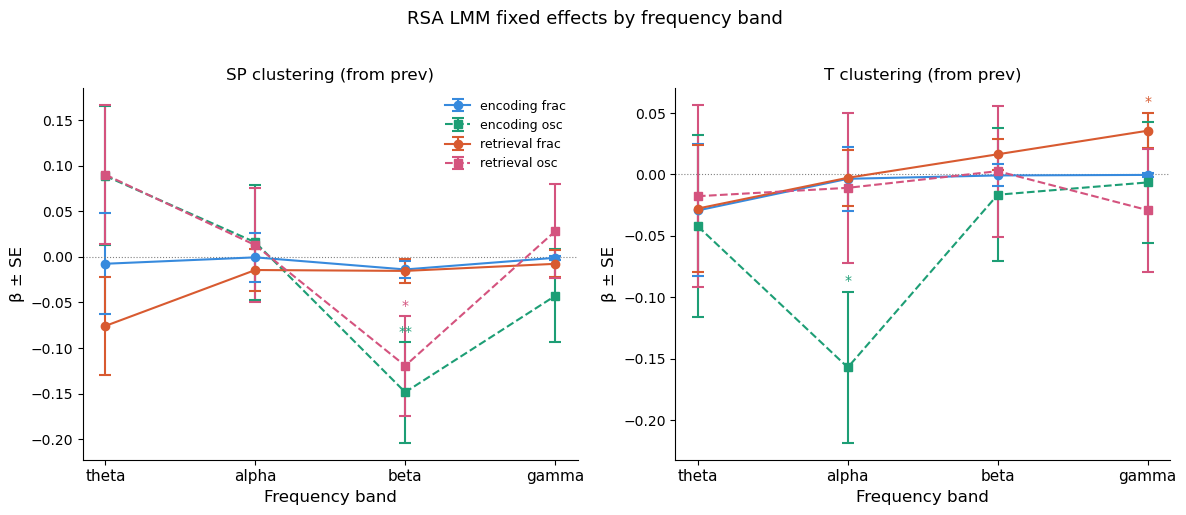

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# LOAD
# ============================================================================

df = pd.read_csv('rsa_band_lmm_results_summary.csv')
df = df[df['predictor'] != 'Intercept'].copy()

# ============================================================================
# CONFIG
# ============================================================================

BANDS      = ['theta', 'alpha', 'beta', 'gamma']
PREDICTORS = ['SP_clustering_from_prev', 'T_clustering_from_prev']
PRED_TITLES = {
    'SP_clustering_from_prev': 'SP clustering (from prev)',
    'T_clustering_from_prev' : 'T clustering (from prev)',
}

# one line per phase x component
GROUPS = [
    ('encoding',  'frac', '#378ADD', 'o', '-',  'encoding frac'),
    ('encoding',  'osc',  '#1D9E75', 's', '--', 'encoding osc'),
    ('retrieval', 'frac', '#D85A30', 'o', '-',  'retrieval frac'),
    ('retrieval', 'osc',  '#D4537E', 's', '--', 'retrieval osc'),
]

def sig_star(p):
    if pd.isna(p): return ''
    if p < 0.001:  return '***'
    if p < 0.01:   return '**'
    if p < 0.05:   return '*'
    return ''

x = np.arange(len(BANDS))

# ============================================================================
# PLOT — one column per predictor
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for ax, pred in zip(axes, PREDICTORS):
    sub = df[df['predictor'] == pred]

    for phase, comp, color, marker, ls, label in GROUPS:
        rows = sub[(sub['phase'] == phase) & (sub['component'] == comp)]
        rows = rows.set_index('band').reindex(BANDS)

        coefs = rows['coef'].values.astype(float)
        ses   = rows['se'].values.astype(float)
        pvals = rows['p'].values.astype(float)

        ax.errorbar(x, coefs, yerr=ses,
                    label=label, color=color,
                    marker=marker, linestyle=ls,
                    linewidth=1.5, markersize=6,
                    capsize=4, capthick=1.5)

        # significance stars
        for i, (c, s, p) in enumerate(zip(coefs, ses, pvals)):
            star = sig_star(p)
            if star:
                ax.text(x[i], c + s + 0.003, star,
                        ha='center', va='bottom',
                        fontsize=10, color=color)

    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xticks(x)
    ax.set_xticklabels(BANDS, fontsize=11)
    ax.set_xlabel('Frequency band', fontsize=12)
    ax.set_ylabel('β ± SE', fontsize=12)
    ax.set_title(PRED_TITLES[pred], fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].legend(fontsize=9, frameon=False)

fig.suptitle('RSA LMM fixed effects by frequency band', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('rsa_lmm_beta_by_band.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# ── RSA pre-flight diagnostic ─────────────────────────────────────────────
print("\n── Trial size distribution (words per trial) ──")
trial_sizes = word_level.groupby(['subject', 'session', 'trial']).size()
print(trial_sizes.value_counts().sort_index().to_string())
print(f"\n  Trials with ≥3 words (RSA computable): "
      f"{(trial_sizes >= 3).sum()} / {len(trial_sizes)}")

print("\n── Pattern vector spot-check (first 3 words) ──")
for i, row in word_level.head(3).iterrows():
    vec = row.get('_vec_encoding_frac_theta', None)
    print(f"  idx={i}  subject={row['subject']}  trial={row['trial']}  "
          f"recall_pos={row.get('_recall_pos', '?')}  "
          f"vec={'None' if vec is None else f'len={len(vec)} nans={np.isnan(vec).sum()}'}")


── Trial size distribution (words per trial) ──
3     47
4     54
5     42
6     31
7     20
8     10
9     10
10     2
11     1

  Trials with ≥3 words (RSA computable): 217 / 217

── Pattern vector spot-check (first 3 words) ──
  idx=0  subject=R1494D  trial=0  recall_pos=?  vec=None
  idx=1  subject=R1494D  trial=0  recall_pos=?  vec=None
  idx=2  subject=R1494D  trial=0  recall_pos=?  vec=None


Loading ALL_SUBJECTS_word_level_rsa_bands.csv ...
  1,094 rows, 36 subjects
rsa_frac_encoding_theta  |  SP_clustering_to_next  |  N=877  OK
rsa_frac_encoding_theta  |  T_clustering_to_next  |  N=877  OK
rsa_frac_encoding_alpha  |  SP_clustering_to_next  |  N=877  OK
rsa_frac_encoding_alpha  |  T_clustering_to_next  |  N=877  OK
rsa_frac_encoding_beta  |  SP_clustering_to_next  |  N=877  OK
rsa_frac_encoding_beta  |  T_clustering_to_next  |  N=877  OK
rsa_frac_encoding_gamma  |  SP_clustering_to_next  |  N=877  OK
rsa_frac_encoding_gamma  |  T_clustering_to_next  |  N=877  OK
rsa_osc_encoding_theta  |  SP_clustering_to_next  |  N=877  OK
rsa_osc_encoding_theta  |  T_clustering_to_next  |  N=877  OK
rsa_osc_encoding_alpha  |  SP_clustering_to_next  |  N=877  OK
rsa_osc_encoding_alpha  |  T_clustering_to_next  |  N=877  OK
rsa_osc_encoding_beta  |  SP_clustering_to_next  |  N=877  OK
rsa_osc_encoding_beta  |  T_clustering_to_next  |  N=877  OK
rsa_osc_encoding_gamma  |  SP_clustering_to_n

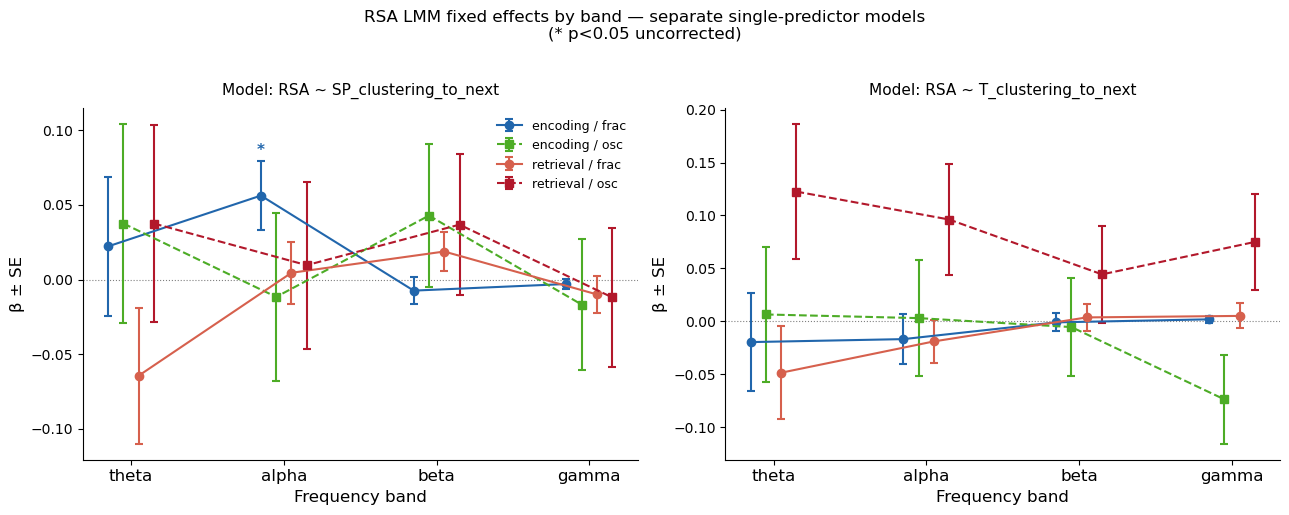

✓ Figure saved → rsa_lmm_beta_by_band.png


In [23]:
"""
Linear Mixed Models: Clustering scores → Band-specific RSA
-----------------------------------------------------------
Two separate models per outcome:
    Model 1: RSA ~ SP_clustering_from_prev + (1|subject) + (1|subj_sess)
    Model 2: RSA ~ T_clustering_from_prev  + (1|subject) + (1|subj_sess)

Input : ALL_SUBJECTS_word_level_rsa_bands.csv
Output: rsa_band_lmm_results_summary.csv
        rsa_lmm_beta_by_band.png
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV  = 'ALL_SUBJECTS_word_level_rsa_bands.csv'
OUTPUT_CSV = 'rsa_band_lmm_results_summary.csv'

PHASES     = ['encoding', 'retrieval']
COMPONENTS = ['frac', 'osc']
BANDS      = ['theta', 'alpha', 'beta', 'gamma']
PREDICTORS = ['SP_clustering_to_next', 'T_clustering_to_next']

# ============================================================================
# LOAD
# ============================================================================

print(f"Loading {INPUT_CSV} ...")
df = pd.read_csv(INPUT_CSV)
df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)
print(f"  {len(df):,} rows, {df['subject'].nunique()} subjects")

RSA_OUTCOMES = [
    f'rsa_{comp}_{phase}_{band}'
    for phase in PHASES
    for comp in COMPONENTS
    for band in BANDS
]

# ============================================================================
# FIT — one model per outcome × predictor
# ============================================================================

all_results = []

for outcome in RSA_OUTCOMES:
    _, comp, phase, band = outcome.split('_', 3)

    for pred in PREDICTORS:
        cols = [outcome, pred, 'subject', 'subj_sess']
        sub  = df[cols].dropna().copy()

        print(f"{outcome}  |  {pred}  |  N={len(sub)}", end='  ')

        if len(sub) < 30:
            print("SKIP")
            continue

        try:
            model  = smf.mixedlm(
                f"{outcome} ~ {pred}",
                data       = sub,
                groups     = sub['subject'],
                vc_formula = {'subj_sess': '0 + C(subj_sess)'},
            )
            result = model.fit(method='lbfgs', maxiter=200, reml=True)

            fe = result.fe_params
            se = result.bse_fe
            zv = result.tvalues
            pv = result.pvalues

            for param in fe.index:
                all_results.append({
                    'outcome'   : outcome,
                    'phase'     : phase,
                    'component' : comp,
                    'band'      : band,
                    'predictor' : param,
                    'model_pred': pred,       # which single-predictor model this came from
                    'coef'      : fe[param],
                    'se'        : se[param],
                    'z'         : zv[param],
                    'p'         : pv[param],
                    'n_obs'     : int(result.nobs),
                    'converged' : result.converged,
                })
            print("OK" if result.converged else "NO CONVERGE")

        except Exception as e:
            print(f"FAILED: {e}")
            continue

# ============================================================================
# FDR — within each predictor family (16 tests each)
# ============================================================================

summary_df = pd.DataFrame(all_results)
summary_df = summary_df[summary_df['predictor'] != 'Intercept'].copy()

summary_df['p_fdr'] = np.nan
for pred in PREDICTORS:
    mask  = summary_df['model_pred'] == pred
    pvals = summary_df.loc[mask, 'p'].values
    _, p_fdr, _, _ = multipletests(pvals, method='fdr_bh')
    summary_df.loc[mask, 'p_fdr'] = p_fdr
    print(f"FDR {pred}: {mask.sum()} tests, {(p_fdr < 0.05).sum()} survive q<0.05")

def sig_star(p):
    if pd.isna(p): return ''
    if p < 0.001:  return '***'
    if p < 0.01:   return '**'
    if p < 0.05:   return '*'
    return ''

summary_df['sig']     = summary_df['p'].apply(sig_star)
summary_df['sig_fdr'] = summary_df['p_fdr'].apply(sig_star)

summary_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✓ Saved → {OUTPUT_CSV}")

# ============================================================================
# PRINT TABLE
# ============================================================================

print("\n" + "="*70)
print("FIXED EFFECTS (separate single-predictor models)")
print("="*70)

for pred in PREDICTORS:
    print(f"\n{'─'*70}")
    print(f"Model: RSA ~ {pred}")
    print(f"{'─'*70}")
    print(f"  {'Outcome':<42} {'coef':>8} {'SE':>8} {'z':>7} {'p':>8} {'p_fdr':>8} {'':>5}")

    sub_df = summary_df[summary_df['model_pred'] == pred]
    for band in BANDS:
        print(f"\n  [{band.upper()}]")
        for phase in PHASES:
            for comp in COMPONENTS:
                row = sub_df[
                    (sub_df['band'] == phase) |   # guard
                    (sub_df['phase'] == phase)
                ]
                row = sub_df[
                    (sub_df['band']      == band) &
                    (sub_df['phase']     == phase) &
                    (sub_df['component'] == comp)
                ]
                if row.empty: continue
                r = row.iloc[0]
                print(f"    rsa_{comp}_{phase}_{band:<6} "
                      f"{r['coef']:>8.4f} {r['se']:>8.4f} {r['z']:>7.3f} "
                      f"{r['p']:>8.4f} {r['p_fdr']:>8.4f} {r['sig_fdr']:>5}")

# ============================================================================
# PLOT
# ============================================================================

GROUPS = [
    ('encoding',  'frac', '#2166ac', 'o', '-',  'encoding / frac'),
    ('encoding',  'osc',  '#4dac26', 's', '--', 'encoding / osc'),
    ('retrieval', 'frac', '#d6604d', 'o', '-',  'retrieval / frac'),
    ('retrieval', 'osc',  '#b2182b', 's', '--', 'retrieval / osc'),
]

x       = np.arange(len(BANDS))
offsets = np.linspace(-0.15, 0.15, 4)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

for ax, pred in zip(axes, PREDICTORS):
    sub_df = summary_df[summary_df['model_pred'] == pred]

    for (phase, comp, color, marker, ls, label), offset in zip(GROUPS, offsets):
        rows = (sub_df[(sub_df['phase'] == phase) & (sub_df['component'] == comp)]
                .set_index('band').reindex(BANDS))

        coefs = rows['coef'].values.astype(float)
        ses   = rows['se'].values.astype(float)
        pvals = rows['p'].values.astype(float)
        xi    = x + offset

        ax.errorbar(xi, coefs, yerr=ses,
                    label=label, color=color,
                    marker=marker, linestyle=ls,
                    linewidth=1.5, markersize=6,
                    capsize=3, capthick=1.5, zorder=3)

        for i, (c, s, p) in enumerate(zip(coefs, ses, pvals)):
            star = sig_star(p)
            if star:
                ax.text(xi[i], c + s + 0.002, star,
                        ha='center', va='bottom',
                        fontsize=11, color=color, fontweight='bold')

    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xticks(x)
    ax.set_xticklabels(BANDS, fontsize=12)
    ax.set_xlabel('Frequency band', fontsize=12)
    ax.set_ylabel('β ± SE', fontsize=12)
    ax.set_title(f'Model: RSA ~ {pred}', fontsize=11, pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].legend(fontsize=9, frameon=False, loc='upper right')
fig.suptitle('RSA LMM fixed effects by band — separate single-predictor models\n'
             '(* p<0.05 uncorrected)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('rsa_lmm_beta_by_band.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved → rsa_lmm_beta_by_band.png")

Loading ALL_SUBJECTS_word_level_rsa_bands.csv ...
  1,094 rows, 36 subjects
rsa_frac_encoding_theta  |  SP_clustering_from_prev  |  N=660  OK
rsa_frac_encoding_theta  |  SP_clustering_to_next  |  N=877  OK
rsa_frac_encoding_theta  |  T_clustering_from_prev  |  N=660  OK
rsa_frac_encoding_theta  |  T_clustering_to_next  |  N=877  OK
rsa_frac_encoding_alpha  |  SP_clustering_from_prev  |  N=660  OK
rsa_frac_encoding_alpha  |  SP_clustering_to_next  |  N=877  OK
rsa_frac_encoding_alpha  |  T_clustering_from_prev  |  N=660  OK
rsa_frac_encoding_alpha  |  T_clustering_to_next  |  N=877  OK
rsa_frac_encoding_beta  |  SP_clustering_from_prev  |  N=660  OK
rsa_frac_encoding_beta  |  SP_clustering_to_next  |  N=877  OK
rsa_frac_encoding_beta  |  T_clustering_from_prev  |  N=660  OK
rsa_frac_encoding_beta  |  T_clustering_to_next  |  N=877  OK
rsa_frac_encoding_gamma  |  SP_clustering_from_prev  |  N=660  OK
rsa_frac_encoding_gamma  |  SP_clustering_to_next  |  N=877  OK
rsa_frac_encoding_gamma 

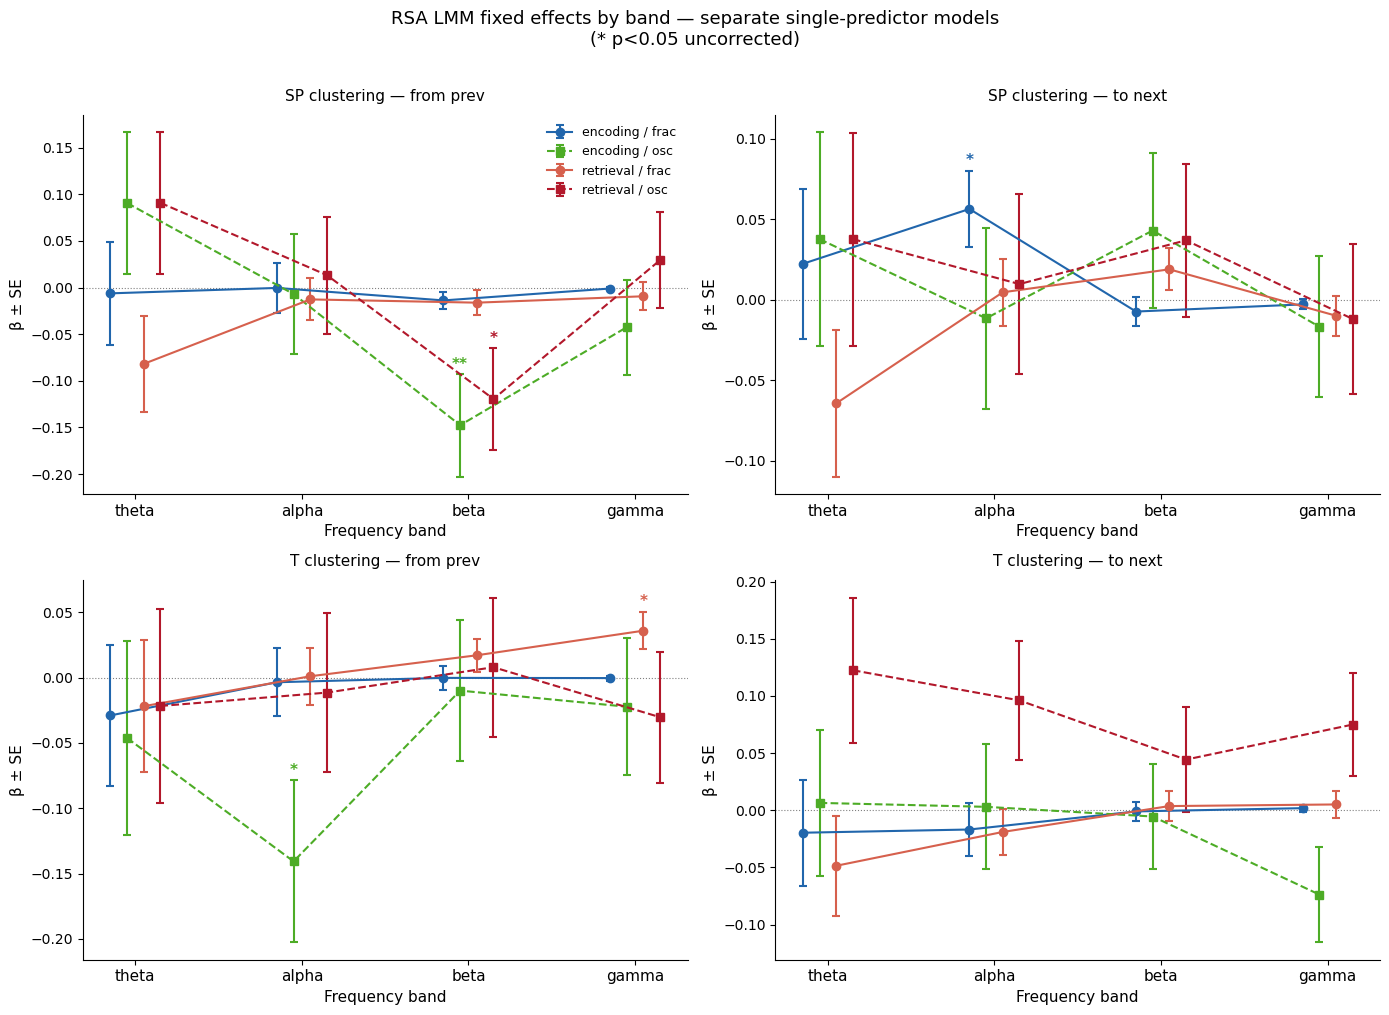

✓ Figure saved → rsa_lmm_beta_by_band.png


In [21]:
"""
Linear Mixed Models: Clustering scores → Band-specific RSA
-----------------------------------------------------------
Two separate models per outcome:
    Model 1: RSA ~ SP_clustering_from_prev + (1|subject) + (1|subj_sess)
    Model 2: RSA ~ T_clustering_from_prev  + (1|subject) + (1|subj_sess)

Input : ALL_SUBJECTS_word_level_rsa_bands.csv
Output: rsa_band_lmm_results_summary.csv
        rsa_lmm_beta_by_band.png
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV  = 'ALL_SUBJECTS_word_level_rsa_bands.csv'
OUTPUT_CSV = 'rsa_band_lmm_results_summary.csv'

PHASES     = ['encoding', 'retrieval']
COMPONENTS = ['frac', 'osc']
BANDS      = ['theta', 'alpha', 'beta', 'gamma']
PREDICTORS = [
    'SP_clustering_from_prev', 'SP_clustering_to_next',
    'T_clustering_from_prev',  'T_clustering_to_next',
]

# ============================================================================
# LOAD
# ============================================================================

print(f"Loading {INPUT_CSV} ...")
df = pd.read_csv(INPUT_CSV)
df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)
print(f"  {len(df):,} rows, {df['subject'].nunique()} subjects")

RSA_OUTCOMES = [
    f'rsa_{comp}_{phase}_{band}'
    for phase in PHASES
    for comp in COMPONENTS
    for band in BANDS
]

# ============================================================================
# FIT — one model per outcome × predictor
# ============================================================================

all_results = []

for outcome in RSA_OUTCOMES:
    _, comp, phase, band = outcome.split('_', 3)

    for pred in PREDICTORS:
        cols = [outcome, pred, 'subject', 'subj_sess']
        sub  = df[cols].dropna().copy()

        print(f"{outcome}  |  {pred}  |  N={len(sub)}", end='  ')

        if len(sub) < 30:
            print("SKIP")
            continue

        try:
            model  = smf.mixedlm(
                f"{outcome} ~ {pred}",
                data       = sub,
                groups     = sub['subject'],
                vc_formula = {'subj_sess': '0 + C(subj_sess)'},
            )
            result = model.fit(method='lbfgs', maxiter=200, reml=True)

            fe = result.fe_params
            se = result.bse_fe
            zv = result.tvalues
            pv = result.pvalues

            for param in fe.index:
                all_results.append({
                    'outcome'   : outcome,
                    'phase'     : phase,
                    'component' : comp,
                    'band'      : band,
                    'predictor' : param,
                    'model_pred': pred,       # which single-predictor model this came from
                    'coef'      : fe[param],
                    'se'        : se[param],
                    'z'         : zv[param],
                    'p'         : pv[param],
                    'n_obs'     : int(result.nobs),
                    'converged' : result.converged,
                })
            print("OK" if result.converged else "NO CONVERGE")

        except Exception as e:
            print(f"FAILED: {e}")
            continue

# ============================================================================
# FDR — within each predictor family (16 tests each)
# ============================================================================

summary_df = pd.DataFrame(all_results)
summary_df = summary_df[summary_df['predictor'] != 'Intercept'].copy()

summary_df['p_fdr'] = np.nan
for pred in PREDICTORS:
    mask  = summary_df['model_pred'] == pred
    pvals = summary_df.loc[mask, 'p'].values
    _, p_fdr, _, _ = multipletests(pvals, method='fdr_bh')
    summary_df.loc[mask, 'p_fdr'] = p_fdr
    print(f"FDR {pred}: {mask.sum()} tests, {(p_fdr < 0.05).sum()} survive q<0.05")

def sig_star(p):
    if pd.isna(p): return ''
    if p < 0.001:  return '***'
    if p < 0.01:   return '**'
    if p < 0.05:   return '*'
    return ''

summary_df['sig']     = summary_df['p'].apply(sig_star)
summary_df['sig_fdr'] = summary_df['p_fdr'].apply(sig_star)

summary_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✓ Saved → {OUTPUT_CSV}")

# ============================================================================
# PRINT TABLE
# ============================================================================

print("\n" + "="*70)
print("FIXED EFFECTS (separate single-predictor models)")
print("="*70)

for pred in PREDICTORS:
    print(f"\n{'─'*70}")
    print(f"Model: RSA ~ {pred}")
    print(f"{'─'*70}")
    print(f"  {'Outcome':<42} {'coef':>8} {'SE':>8} {'z':>7} {'p':>8} {'p_fdr':>8} {'':>5}")

    sub_df = summary_df[summary_df['model_pred'] == pred]
    for band in BANDS:
        print(f"\n  [{band.upper()}]")
        for phase in PHASES:
            for comp in COMPONENTS:
                row = sub_df[
                    (sub_df['band'] == phase) |   # guard
                    (sub_df['phase'] == phase)
                ]
                row = sub_df[
                    (sub_df['band']      == band) &
                    (sub_df['phase']     == phase) &
                    (sub_df['component'] == comp)
                ]
                if row.empty: continue
                r = row.iloc[0]
                print(f"    rsa_{comp}_{phase}_{band:<6} "
                      f"{r['coef']:>8.4f} {r['se']:>8.4f} {r['z']:>7.3f} "
                      f"{r['p']:>8.4f} {r['p_fdr']:>8.4f} {r['sig_fdr']:>5}")

# ============================================================================
# PLOT
# ============================================================================

GROUPS = [
    ('encoding',  'frac', '#2166ac', 'o', '-',  'encoding / frac'),
    ('encoding',  'osc',  '#4dac26', 's', '--', 'encoding / osc'),
    ('retrieval', 'frac', '#d6604d', 'o', '-',  'retrieval / frac'),
    ('retrieval', 'osc',  '#b2182b', 's', '--', 'retrieval / osc'),
]

x       = np.arange(len(BANDS))
offsets = np.linspace(-0.15, 0.15, 4)

PRED_TITLES = {
    'SP_clustering_from_prev': 'SP clustering — from prev',
    'SP_clustering_to_next':   'SP clustering — to next',
    'T_clustering_from_prev':  'T clustering — from prev',
    'T_clustering_to_next':    'T clustering — to next',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes_flat = axes.flatten()  # [SP_from, SP_to, T_from, T_to]

for ax, pred in zip(axes_flat, PREDICTORS):
    sub_df = summary_df[summary_df['model_pred'] == pred]

    for (phase, comp, color, marker, ls, label), offset in zip(GROUPS, offsets):
        rows = (sub_df[(sub_df['phase'] == phase) & (sub_df['component'] == comp)]
                .set_index('band').reindex(BANDS))

        coefs = rows['coef'].values.astype(float)
        ses   = rows['se'].values.astype(float)
        pvals = rows['p'].values.astype(float)
        xi    = x + offset

        ax.errorbar(xi, coefs, yerr=ses,
                    label=label, color=color,
                    marker=marker, linestyle=ls,
                    linewidth=1.5, markersize=6,
                    capsize=3, capthick=1.5, zorder=3)

        for i, (c, s, p) in enumerate(zip(coefs, ses, pvals)):
            star = sig_star(p)
            if star:
                ax.text(xi[i], c + s + 0.002, star,
                        ha='center', va='bottom',
                        fontsize=11, color=color, fontweight='bold')

    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xticks(x)
    ax.set_xticklabels(BANDS, fontsize=11)
    ax.set_xlabel('Frequency band', fontsize=11)
    ax.set_ylabel('β ± SE', fontsize=11)
    ax.set_title(PRED_TITLES[pred], fontsize=11, pad=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes_flat[0].legend(fontsize=9, frameon=False, loc='upper right')
fig.suptitle('RSA LMM fixed effects by band — separate single-predictor models\n'
             '(* p<0.05 uncorrected)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('rsa_lmm_beta_by_band.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure saved → rsa_lmm_beta_by_band.png")

In [24]:
"""
Model 5: connectivity ~ recalled + frac_ssl_z + osc_ssl_z  (both regions separately)
============================================================================
Adds frac and osc as joint covariates in a single model.
This lets you ask: after controlling for BOTH spectral components simultaneously,
does the recalled effect survive, and do the two components have independent effects?

Slot this block into retrieval_plv_pli_analysis.py after the existing Model 4 blocks.
Assumes the following are already defined in the script:
  - df           : master dataframe with subj_sess column and z-scored columns
  - freqs        : sorted array of unique freq_hz values
  - fit_lme_nested(formula, data) -> (result, fell_back)
  - sig_str(p_unc, p_fdr) -> string
  - fdrcorrection
"""

import pandas as pd
import numpy as np
from statsmodels.stats.multitest import fdrcorrection

# ── Model 5a: metric ~ recalled + frac_ssl_lhp_z + osc_ssl_lhp_z ─────────────
print('Model 5a: metric ~ recalled + frac_ssl_lhp_z + osc_ssl_lhp_z ...')

results_m5a = []
for metric in ['plv', 'pli', 'dpli']:
    for freq in freqs:
        sub = df[df['freq_hz'] == freq].copy()
        try:
            mdf, fell_back = fit_lme_nested(
                f'{metric} ~ recalled + frac_ssl_lhp_z + osc_ssl_lhp_z', sub)
            for term in ['recalled', 'frac_ssl_lhp_z', 'osc_ssl_lhp_z']:
                results_m5a.append({
                    'metric':   metric,
                    'freq_hz':  freq,
                    'term':     term,
                    'coef':     mdf.params[term],
                    'se':       mdf.bse[term],
                    'tval':     mdf.tvalues[term],
                    'pval':     mdf.pvalues[term],
                    'fell_back': fell_back,
                })
        except Exception:
            for term in ['recalled', 'frac_ssl_lhp_z', 'osc_ssl_lhp_z']:
                results_m5a.append({
                    'metric': metric, 'freq_hz': freq, 'term': term,
                    'coef': np.nan, 'se': np.nan, 'tval': np.nan, 'pval': np.nan,
                    'fell_back': True,
                })

lme5a = pd.DataFrame(results_m5a)

# FDR per metric × term across frequencies
for met in ['plv', 'pli', 'dpli']:
    for term in ['recalled', 'frac_ssl_lhp_z', 'osc_ssl_lhp_z']:
        mask = (lme5a['metric'] == met) & (lme5a['term'] == term)
        pvals = lme5a.loc[mask, 'pval'].values
        valid = ~np.isnan(pvals)
        fdr = np.full_like(pvals, np.nan)
        if valid.sum() > 0:
            _, fdr[valid] = fdrcorrection(pvals[valid], alpha=0.05)
        lme5a.loc[mask, 'pval_fdr'] = fdr
        lme5a.loc[mask, 'sig_fdr']  = fdr < 0.05


# ── Model 5b: metric ~ recalled + frac_ssl_lltc_z + osc_ssl_lltc_z ───────────
print('Model 5b: metric ~ recalled + frac_ssl_lltc_z + osc_ssl_lltc_z ...')

results_m5b = []
for metric in ['plv', 'pli', 'dpli']:
    for freq in freqs:
        sub = df[df['freq_hz'] == freq].copy()
        try:
            mdf, fell_back = fit_lme_nested(
                f'{metric} ~ recalled + frac_ssl_lltc_z + osc_ssl_lltc_z', sub)
            for term in ['recalled', 'frac_ssl_lltc_z', 'osc_ssl_lltc_z']:
                results_m5b.append({
                    'metric':   metric,
                    'freq_hz':  freq,
                    'term':     term,
                    'coef':     mdf.params[term],
                    'se':       mdf.bse[term],
                    'tval':     mdf.tvalues[term],
                    'pval':     mdf.pvalues[term],
                    'fell_back': fell_back,
                })
        except Exception:
            for term in ['recalled', 'frac_ssl_lltc_z', 'osc_ssl_lltc_z']:
                results_m5b.append({
                    'metric': metric, 'freq_hz': freq, 'term': term,
                    'coef': np.nan, 'se': np.nan, 'tval': np.nan, 'pval': np.nan,
                    'fell_back': True,
                })

lme5b = pd.DataFrame(results_m5b)

for met in ['plv', 'pli', 'dpli']:
    for term in ['recalled', 'frac_ssl_lltc_z', 'osc_ssl_lltc_z']:
        mask = (lme5b['metric'] == met) & (lme5b['term'] == term)
        pvals = lme5b.loc[mask, 'pval'].values
        valid = ~np.isnan(pvals)
        fdr = np.full_like(pvals, np.nan)
        if valid.sum() > 0:
            _, fdr[valid] = fdrcorrection(pvals[valid], alpha=0.05)
        lme5b.loc[mask, 'pval_fdr'] = fdr
        lme5b.loc[mask, 'sig_fdr']  = fdr < 0.05


# ── Save ──────────────────────────────────────────────────────────────────────
lme5a.to_csv('lme5a_metric_recalled_frac_osc_lhp.csv', index=False)
lme5b.to_csv('lme5b_metric_recalled_frac_osc_lltc.csv', index=False)


# ── Print summary tables ──────────────────────────────────────────────────────
def sig_str(p_unc, p_fdr):
    if p_fdr < 0.001: return '***'
    if p_fdr < 0.01:  return '**'
    if p_fdr < 0.05:  return '*'
    if p_unc < 0.05:  return '†'
    return ''

print('\n' + '=' * 90)
print('MODEL 5a: metric ~ recalled + frac_ssl_lhp_z + osc_ssl_lhp_z')
print('=' * 90)
for met in ['plv', 'pli', 'dpli']:
    print(f'\n── {met.upper()} ──')
    for term in ['recalled', 'frac_ssl_lhp_z', 'osc_ssl_lhp_z']:
        sub_df = lme5a[(lme5a['metric'] == met) & (lme5a['term'] == term)]
        print(f'\n  Term: {term}')
        print(f'  {"Freq":>8} {"β":>10} {"SE":>10} {"t":>8} {"p":>8} {"p(FDR)":>8} {"sig":>5}')
        print('  ' + '-' * 64)
        for _, r in sub_df.iterrows():
            s = sig_str(r['pval'], r['pval_fdr'])
            print(f'  {r["freq_hz"]:8.1f} {r["coef"]:10.5f} {r["se"]:10.5f} '
                  f'{r["tval"]:8.2f} {r["pval"]:8.4f} {r["pval_fdr"]:8.4f} {s:>5}')

print('\n' + '=' * 90)
print('MODEL 5b: metric ~ recalled + frac_ssl_lltc_z + osc_ssl_lltc_z')
print('=' * 90)
for met in ['plv', 'pli', 'dpli']:
    print(f'\n── {met.upper()} ──')
    for term in ['recalled', 'frac_ssl_lltc_z', 'osc_ssl_lltc_z']:
        sub_df = lme5b[(lme5b['metric'] == met) & (lme5b['term'] == term)]
        print(f'\n  Term: {term}')
        print(f'  {"Freq":>8} {"β":>10} {"SE":>10} {"t":>8} {"p":>8} {"p(FDR)":>8} {"sig":>5}')
        print('  ' + '-' * 64)
        for _, r in sub_df.iterrows():
            s = sig_str(r['pval'], r['pval_fdr'])
            print(f'  {r["freq_hz"]:8.1f} {r["coef"]:10.5f} {r["se"]:10.5f} '
                  f'{r["tval"]:8.2f} {r["pval"]:8.4f} {r["pval_fdr"]:8.4f} {s:>5}')

Model 5a: metric ~ recalled + frac_ssl_lhp_z + osc_ssl_lhp_z ...


KeyError: 'freq_hz'

In [25]:
"""
Linear Mixed Models: Clustering scores → Band-specific RSA
-----------------------------------------------------------
Three models per outcome:
    Model 1: RSA ~ SP_clustering_from_prev + (1|subject) + (1|subj_sess)
    Model 2: RSA ~ T_clustering_from_prev  + (1|subject) + (1|subj_sess)
    Model 3: RSA ~ SP_clustering_from_prev + T_clustering_from_prev  (joint)
    (same pattern repeated for _to_next variants)

Input : ALL_SUBJECTS_word_level_rsa_bands.csv
Output: rsa_band_lmm_results_summary.csv
        rsa_lmm_beta_by_band.png
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIG
# ============================================================================

INPUT_CSV  = 'ALL_SUBJECTS_word_level_rsa_bands.csv'
OUTPUT_CSV = 'rsa_band_lmm_results_summary.csv'

PHASES     = ['encoding', 'retrieval']
COMPONENTS = ['frac', 'osc']
BANDS      = ['theta', 'alpha', 'beta', 'gamma']

# Single-predictor models (unchanged)
PREDICTORS = [
    'SP_clustering_from_prev', 'SP_clustering_to_next',
    'T_clustering_from_prev',  'T_clustering_to_next',
]

# Joint models: both SP and T together
JOINT_MODELS = [
    {
        'name'  : 'SP+T_from_prev',
        'formula_rhs': 'SP_clustering_from_prev + T_clustering_from_prev',
        'terms' : ['SP_clustering_from_prev', 'T_clustering_from_prev'],
    },
    {
        'name'  : 'SP+T_to_next',
        'formula_rhs': 'SP_clustering_to_next + T_clustering_to_next',
        'terms' : ['SP_clustering_to_next', 'T_clustering_to_next'],
    },
]

# ============================================================================
# LOAD
# ============================================================================

print(f"Loading {INPUT_CSV} ...")
df = pd.read_csv(INPUT_CSV)
df['subj_sess'] = df['subject'].astype(str) + '_' + df['session'].astype(str)
print(f"  {len(df):,} rows, {df['subject'].nunique()} subjects")

RSA_OUTCOMES = [
    f'rsa_{comp}_{phase}_{band}'
    for phase in PHASES
    for comp in COMPONENTS
    for band in BANDS
]

def sig_star(p):
    if pd.isna(p): return ''
    if p < 0.001:  return '***'
    if p < 0.01:   return '**'
    if p < 0.05:   return '*'
    return ''

# ============================================================================
# FIT — single-predictor models (Models 1 & 2)
# ============================================================================

all_results = []

for outcome in RSA_OUTCOMES:
    _, comp, phase, band = outcome.split('_', 3)

    for pred in PREDICTORS:
        cols = [outcome, pred, 'subject', 'subj_sess']
        sub  = df[cols].dropna().copy()
        print(f"{outcome}  |  {pred}  |  N={len(sub)}", end='  ')
        if len(sub) < 30:
            print("SKIP"); continue
        try:
            model  = smf.mixedlm(
                f"{outcome} ~ {pred}",
                data       = sub,
                groups     = sub['subject'],
                vc_formula = {'subj_sess': '0 + C(subj_sess)'},
            )
            result = model.fit(method='lbfgs', maxiter=200, reml=True)
            fe, se, zv, pv = result.fe_params, result.bse_fe, result.tvalues, result.pvalues
            for param in fe.index:
                all_results.append({
                    'outcome'    : outcome,
                    'phase'      : phase,
                    'component'  : comp,
                    'band'       : band,
                    'predictor'  : param,
                    'model_name' : pred,
                    'model_type' : 'single',
                    'coef'       : fe[param],
                    'se'         : se[param],
                    'z'          : zv[param],
                    'p'          : pv[param],
                    'n_obs'      : int(result.nobs),
                    'converged'  : result.converged,
                })
            print("OK" if result.converged else "NO CONVERGE")
        except Exception as e:
            print(f"FAILED: {e}")

# ============================================================================
# FIT — joint models (Model 3: SP + T together)
# ============================================================================

print("\n--- Joint models (SP + T combined) ---")

joint_results = []

for outcome in RSA_OUTCOMES:
    _, comp, phase, band = outcome.split('_', 3)

    for jm in JOINT_MODELS:
        cols = [outcome] + jm['terms'] + ['subject', 'subj_sess']
        sub  = df[cols].dropna().copy()
        print(f"{outcome}  |  {jm['name']}  |  N={len(sub)}", end='  ')
        if len(sub) < 30:
            print("SKIP"); continue
        try:
            model  = smf.mixedlm(
                f"{outcome} ~ {jm['formula_rhs']}",
                data       = sub,
                groups     = sub['subject'],
                vc_formula = {'subj_sess': '0 + C(subj_sess)'},
            )
            result = model.fit(method='lbfgs', maxiter=200, reml=True)
            fe, se, zv, pv = result.fe_params, result.bse_fe, result.tvalues, result.pvalues
            for param in fe.index:
                joint_results.append({
                    'outcome'    : outcome,
                    'phase'      : phase,
                    'component'  : comp,
                    'band'       : band,
                    'predictor'  : param,
                    'model_name' : jm['name'],
                    'model_type' : 'joint',
                    'coef'       : fe[param],
                    'se'         : se[param],
                    'z'          : zv[param],
                    'p'          : pv[param],
                    'n_obs'      : int(result.nobs),
                    'converged'  : result.converged,
                })
            print("OK" if result.converged else "NO CONVERGE")
        except Exception as e:
            print(f"FAILED: {e}")

# ============================================================================
# COMBINE & FDR
# ============================================================================

summary_df = pd.DataFrame(all_results + joint_results)
summary_df = summary_df[summary_df['predictor'] != 'Intercept'].copy()

summary_df['p_fdr'] = np.nan

# FDR for single-predictor models: within each predictor family (16 tests)
for pred in PREDICTORS:
    mask  = (summary_df['model_type'] == 'single') & (summary_df['model_name'] == pred)
    pvals = summary_df.loc[mask, 'p'].values
    if mask.sum() == 0: continue
    _, p_fdr, _, _ = multipletests(pvals, method='fdr_bh')
    summary_df.loc[mask, 'p_fdr'] = p_fdr
    print(f"FDR {pred}: {mask.sum()} tests, {(p_fdr < 0.05).sum()} survive q<0.05")

# FDR for joint models: within each joint model × term (16 tests per term)
for jm in JOINT_MODELS:
    for term in jm['terms']:
        mask = (
            (summary_df['model_type'] == 'joint') &
            (summary_df['model_name'] == jm['name']) &
            (summary_df['predictor']  == term)
        )
        pvals = summary_df.loc[mask, 'p'].values
        if mask.sum() == 0: continue
        _, p_fdr, _, _ = multipletests(pvals, method='fdr_bh')
        summary_df.loc[mask, 'p_fdr'] = p_fdr
        print(f"FDR joint {jm['name']} / {term}: {mask.sum()} tests, {(p_fdr < 0.05).sum()} survive q<0.05")

summary_df['sig']     = summary_df['p'].apply(sig_star)
summary_df['sig_fdr'] = summary_df['p_fdr'].apply(sig_star)
summary_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✓ Saved → {OUTPUT_CSV}")

# ============================================================================
# PRINT TABLE — joint models
# ============================================================================

print("\n" + "="*70)
print("JOINT MODEL FIXED EFFECTS (SP + T clustering together)")
print("="*70)

for jm in JOINT_MODELS:
    for term in jm['terms']:
        print(f"\n{'─'*70}")
        print(f"Model: RSA ~ {jm['formula_rhs']}   |   Term: {term}")
        print(f"{'─'*70}")
        print(f"  {'Outcome':<42} {'coef':>8} {'SE':>8} {'z':>7} {'p':>8} {'p_fdr':>8} {'':>5}")

        sub_df = summary_df[
            (summary_df['model_name'] == jm['name']) &
            (summary_df['predictor']  == term)
        ]
        for band in BANDS:
            print(f"\n  [{band.upper()}]")
            for phase in PHASES:
                for comp in COMPONENTS:
                    row = sub_df[
                        (sub_df['band']      == band) &
                        (sub_df['phase']     == phase) &
                        (sub_df['component'] == comp)
                    ]
                    if row.empty: continue
                    r = row.iloc[0]
                    print(f"    rsa_{comp}_{phase}_{band:<6} "
                          f"{r['coef']:>8.4f} {r['se']:>8.4f} {r['z']:>7.3f} "
                          f"{r['p']:>8.4f} {r['p_fdr']:>8.4f} {r['sig_fdr']:>5}")

# ============================================================================
# PLOT — 2 rows: single models (top), joint models (bottom)
# ============================================================================

GROUPS = [
    ('encoding',  'frac', '#2166ac', 'o', '-',  'encoding / frac'),
    ('encoding',  'osc',  '#4dac26', 's', '--', 'encoding / osc'),
    ('retrieval', 'frac', '#d6604d', 'o', '-',  'retrieval / frac'),
    ('retrieval', 'osc',  '#b2182b', 's', '--', 'retrieval / osc'),
]

x       = np.arange(len(BANDS))
offsets = np.linspace(-0.15, 0.15, 4)

# ── Figure 1: single-predictor (unchanged layout) ────────────────────────────
PRED_TITLES = {
    'SP_clustering_from_prev': 'SP clustering — from prev',
    'SP_clustering_to_next':   'SP clustering — to next',
    'T_clustering_from_prev':  'T clustering — from prev',
    'T_clustering_to_next':    'T clustering — to next',
}

fig1, axes1 = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
for ax, pred in zip(axes1.flatten(), PREDICTORS):
    sub_df = summary_df[
        (summary_df['model_type'] == 'single') &
        (summary_df['model_name'] == pred)
    ]
    for (phase, comp, color, marker, ls, label), offset in zip(GROUPS, offsets):
        rows  = (sub_df[(sub_df['phase'] == phase) & (sub_df['component'] == comp)]
                 .set_index('band').reindex(BANDS))
        coefs = rows['coef'].values.astype(float)
        ses   = rows['se'].values.astype(float)
        pvals = rows['p'].values.astype(float)
        xi    = x + offset
        ax.errorbar(xi, coefs, yerr=ses, label=label, color=color,
                    marker=marker, linestyle=ls, linewidth=1.5, markersize=6,
                    capsize=3, capthick=1.5, zorder=3)
        for i, (c, s, p) in enumerate(zip(coefs, ses, pvals)):
            star = sig_star(p)
            if star:
                ax.text(xi[i], c + s + 0.002, star,
                        ha='center', va='bottom', fontsize=11,
                        color=color, fontweight='bold')
    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xticks(x); ax.set_xticklabels(BANDS, fontsize=11)
    ax.set_xlabel('Frequency band', fontsize=11)
    ax.set_ylabel('β ± SE', fontsize=11)
    ax.set_title(PRED_TITLES[pred], fontsize=11, pad=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
axes1.flatten()[0].legend(fontsize=9, frameon=False, loc='upper right')
fig1.suptitle('RSA LMM — single-predictor models\n(* p<0.05 uncorrected)',
              fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('rsa_lmm_beta_by_band_single.png', dpi=150, bbox_inches='tight')
print("✓ Figure saved → rsa_lmm_beta_by_band_single.png")

# ── Figure 2: joint models (2 panels: from_prev, to_next) ────────────────────
# Each panel shows SP and T terms side-by-side using distinct colors/markers

JOINT_TERM_STYLE = {
    # (term_suffix, phase, comp) -> (color, marker, ls, label)
    ('SP', 'encoding',  'frac'): ('#2166ac', 'o', '-',  'SP / enc / frac'),
    ('SP', 'encoding',  'osc' ): ('#4dac26', 's', '--', 'SP / enc / osc'),
    ('SP', 'retrieval', 'frac'): ('#d6604d', 'o', '-',  'SP / ret / frac'),
    ('SP', 'retrieval', 'osc' ): ('#b2182b', 's', '--', 'SP / ret / osc'),
    ('T',  'encoding',  'frac'): ('#80b1d3', 'D', '-',  'T  / enc / frac'),
    ('T',  'encoding',  'osc' ): ('#b3de69', 'P', '--', 'T  / enc / osc'),
    ('T',  'retrieval', 'frac'): ('#fb8072', 'D', '-',  'T  / ret / frac'),
    ('T',  'retrieval', 'osc' ): ('#fdb462', 'P', '--', 'T  / ret / osc'),
}

fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
joint_offsets = np.linspace(-0.25, 0.25, 8)

for ax, jm in zip(axes2, JOINT_MODELS):
    sub_df = summary_df[
        (summary_df['model_type'] == 'joint') &
        (summary_df['model_name'] == jm['name'])
    ]
    direction = jm['name'].split('_')[-2] + '_' + jm['name'].split('_')[-1]  # from_prev / to_next

    styles_ordered = []
    for term in jm['terms']:
        prefix = 'SP' if term.startswith('SP') else 'T'
        for phase in PHASES:
            for comp in COMPONENTS:
                styles_ordered.append((term, prefix, phase, comp))

    for (term, prefix, phase, comp), offset in zip(styles_ordered, joint_offsets):
        style_key = (prefix, phase, comp)
        color, marker, ls, label = JOINT_TERM_STYLE[style_key]

        row_df = sub_df[
            (sub_df['predictor']  == term) &
            (sub_df['phase']      == phase) &
            (sub_df['component']  == comp)
        ].set_index('band').reindex(BANDS)

        coefs = row_df['coef'].values.astype(float)
        ses   = row_df['se'].values.astype(float)
        pvals = row_df['p'].values.astype(float)
        xi    = x + offset

        ax.errorbar(xi, coefs, yerr=ses, label=label, color=color,
                    marker=marker, linestyle=ls, linewidth=1.5, markersize=5,
                    capsize=3, capthick=1.2, zorder=3)
        for i, (c, s, p) in enumerate(zip(coefs, ses, pvals)):
            star = sig_star(p)
            if star:
                ax.text(xi[i], c + s + 0.002, star,
                        ha='center', va='bottom', fontsize=10,
                        color=color, fontweight='bold')

    ax.axhline(0, color='gray', linewidth=0.8, linestyle=':')
    ax.set_xticks(x); ax.set_xticklabels(BANDS, fontsize=11)
    ax.set_xlabel('Frequency band', fontsize=11)
    ax.set_ylabel('β ± SE', fontsize=11)
    ax.set_title(f'Joint model: RSA ~ SP + T  ({direction.replace("_", " ")})',
                 fontsize=11, pad=10)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8, frameon=False, loc='upper right', ncol=2)

fig2.suptitle('RSA LMM — joint SP + T clustering models\n(* p<0.05 uncorrected)',
              fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('rsa_lmm_beta_by_band_joint.png', dpi=150, bbox_inches='tight')
print("✓ Figure saved → rsa_lmm_beta_by_band_joint.png")

Loading ALL_SUBJECTS_word_level_rsa_bands.csv ...
  1,094 rows, 36 subjects
rsa_frac_encoding_theta  |  SP_clustering_from_prev  |  N=660  OK
rsa_frac_encoding_theta  |  SP_clustering_to_next  |  N=877  OK
rsa_frac_encoding_theta  |  T_clustering_from_prev  |  N=660  OK
rsa_frac_encoding_theta  |  T_clustering_to_next  |  N=877  OK
rsa_frac_encoding_alpha  |  SP_clustering_from_prev  |  N=660  OK
rsa_frac_encoding_alpha  |  SP_clustering_to_next  |  N=877  OK
rsa_frac_encoding_alpha  |  T_clustering_from_prev  |  N=660  OK
rsa_frac_encoding_alpha  |  T_clustering_to_next  |  N=877  OK
rsa_frac_encoding_beta  |  SP_clustering_from_prev  |  N=660  OK
rsa_frac_encoding_beta  |  SP_clustering_to_next  |  N=877  OK
rsa_frac_encoding_beta  |  T_clustering_from_prev  |  N=660  OK
rsa_frac_encoding_beta  |  T_clustering_to_next  |  N=877  OK
rsa_frac_encoding_gamma  |  SP_clustering_from_prev  |  N=660  OK
rsa_frac_encoding_gamma  |  SP_clustering_to_next  |  N=877  OK
rsa_frac_encoding_gamma 